In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
ts = pd.read_csv('MOD-00679-2-27data.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:42Z,5.711,0.844,0.341,0.071,0.046,0.025,5.908,813.531,27.138,2.469,31.630,49.4,0.2
1,2025-12-31T18:58:42Z,5.916,0.818,0.337,0.107,0.059,0.019,5.851,806.176,27.506,2.584,31.394,49.2,0.1
2,2025-12-31T18:57:42Z,5.734,1.020,0.294,0.103,0.056,0.022,6.511,774.709,27.878,2.584,31.165,49.0,0.1
3,2025-12-31T18:56:42Z,5.723,0.806,0.241,0.078,0.036,0.011,6.824,758.770,28.238,2.584,30.933,48.9,0.1
4,2025-12-31T18:55:42Z,5.317,0.855,0.325,0.087,0.033,0.011,5.973,760.341,27.878,2.584,30.928,49.0,0.1


In [4]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:42,5.711,0.844,0.341,0.071,0.046,0.025,5.908,813.531,27.138,2.469,31.630,49.4,0.2
1,2025-12-31 18:58:42,5.916,0.818,0.337,0.107,0.059,0.019,5.851,806.176,27.506,2.584,31.394,49.2,0.1
2,2025-12-31 18:57:42,5.734,1.020,0.294,0.103,0.056,0.022,6.511,774.709,27.878,2.584,31.165,49.0,0.1
3,2025-12-31 18:56:42,5.723,0.806,0.241,0.078,0.036,0.011,6.824,758.770,28.238,2.584,30.933,48.9,0.1
4,2025-12-31 18:55:42,5.317,0.855,0.325,0.087,0.033,0.011,5.973,760.341,27.878,2.584,30.928,49.0,0.1


## Full Timeseries Plot

In [5]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-15,5.131208,0.591750,0.218333,0.066500,0.064708,0.032875,8.764208,NaN,NaN,NaN,NaN,36.575000,22.020833
2025-04-25,5.531350,0.911095,0.430183,0.159997,0.210502,0.145187,10.001895,939.732182,60.447398,4.710330,16.689666,45.238014,24.217163
2025-04-26,15.429881,2.012256,0.682324,0.250054,0.356299,0.270286,10.109317,778.311522,42.669899,2.085894,17.246674,72.362778,19.973333
2025-04-27,0.954862,0.137442,0.049947,0.015040,0.014190,0.008011,1.148103,650.094649,50.277137,2.032800,15.415752,40.896042,14.760556
2025-04-28,2.615297,0.401429,0.147768,0.041593,0.043414,0.026456,4.389924,760.356719,53.618060,2.349033,13.767081,25.754236,21.548194


In [6]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15,5.131208,0.591750,0.218333,0.066500,0.064708,0.032875,8.764208,NaN,NaN,NaN,NaN,36.575000,22.020833,8.361617
2025-04-25,5.531350,0.911095,0.430183,0.159997,0.210502,0.145187,10.001895,939.732182,60.447398,4.710330,16.689666,45.238014,24.217163,8.821107
2025-04-26,15.429881,2.012256,0.682324,0.250054,0.356299,0.270286,10.109317,778.311522,42.669899,2.085894,17.246674,72.362778,19.973333,7.311049
2025-04-27,0.954862,0.137442,0.049947,0.015040,0.014190,0.008011,1.148103,650.094649,50.277137,2.032800,15.415752,40.896042,14.760556,3.263432
2025-04-28,2.615297,0.401429,0.147768,0.041593,0.043414,0.026456,4.389924,760.356719,53.618060,2.349033,13.767081,25.754236,21.548194,6.317521


<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-459/1079412165.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}]",fontsize=14)


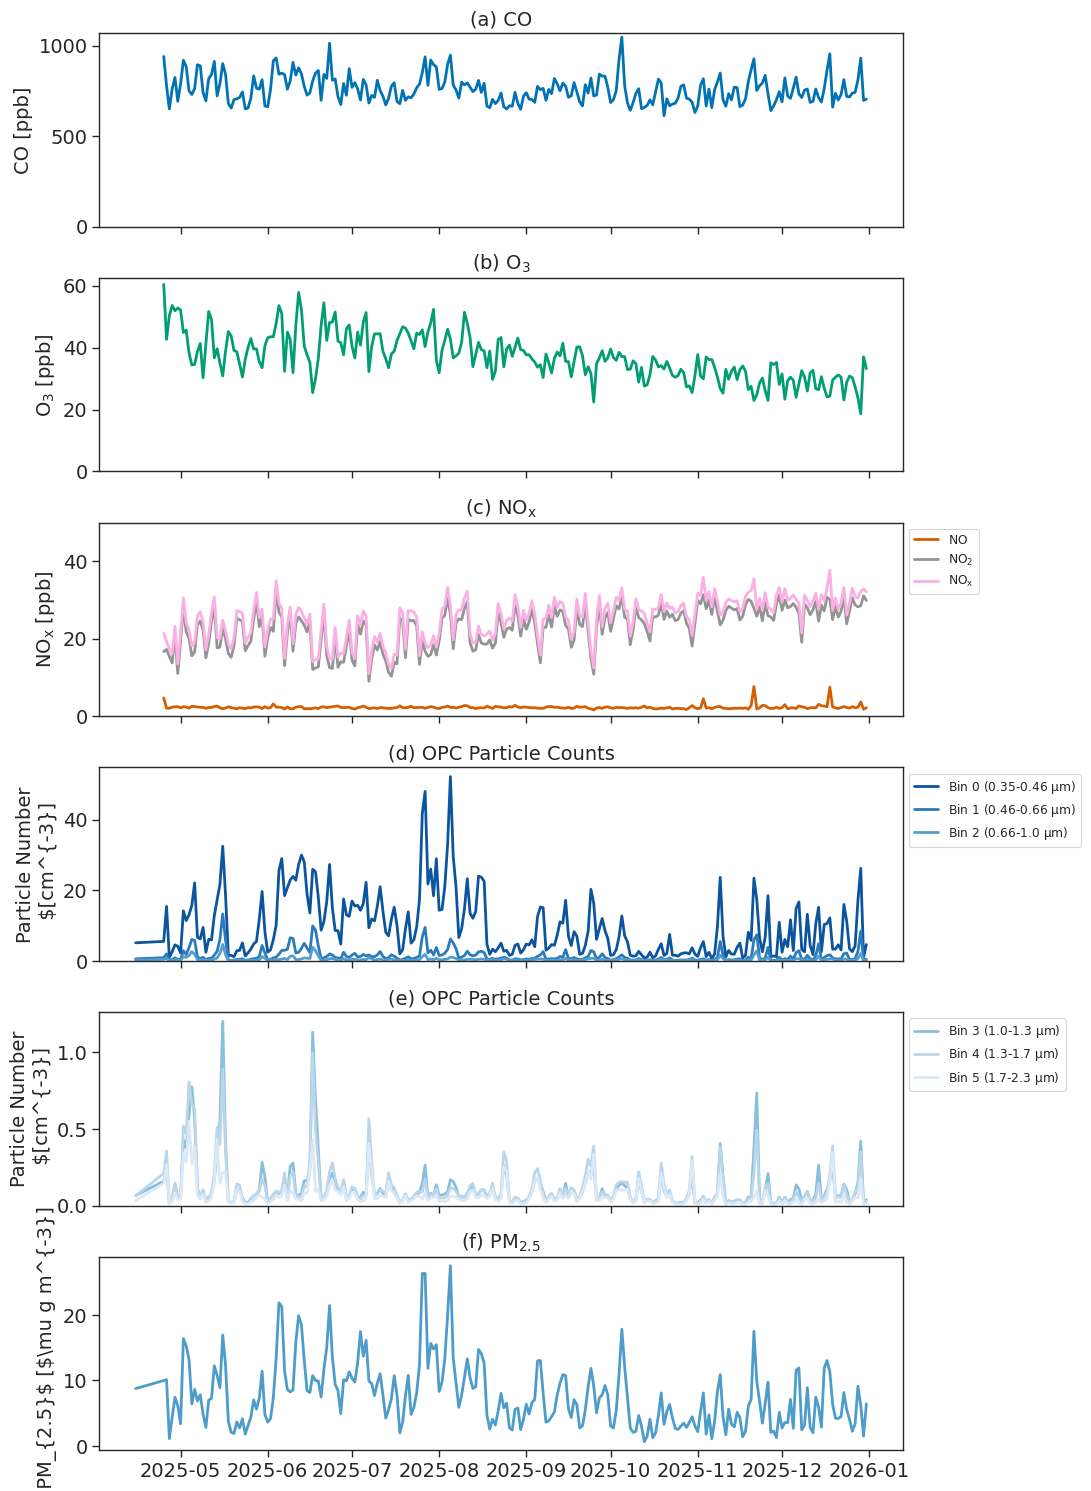

In [7]:
import os

# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

os.makedirs('MOD-00679', exist_ok=True)
fig.savefig('MOD-00679/timeseries_MOD-000679.png')

## Dirunal Plots

In [8]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-15 08:00:00,5.131208,0.591750,0.218333,0.066500,0.064708,0.032875,8.764208,NaN,NaN,NaN,NaN,36.575000,22.020833
2025-04-25 10:00:00,2.892933,0.370733,0.137533,0.042533,0.031000,0.013733,3.812400,NaN,NaN,NaN,NaN,38.166667,23.046667
2025-04-25 11:00:00,2.891000,0.350600,0.123000,0.041200,0.032200,0.010200,3.761200,NaN,NaN,NaN,NaN,41.160000,23.180000
2025-04-25 12:00:00,6.251560,0.860040,0.320480,0.102760,0.138800,0.092240,9.620120,NaN,NaN,NaN,NaN,29.908000,28.064000
2025-04-25 13:00:00,7.201600,0.838100,0.351233,0.113567,0.142867,0.093833,10.760467,1224.4478,72.87552,5.96976,6.93636,30.555000,29.026667


In [9]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15 08:00:00,5.131208,0.591750,0.218333,0.066500,0.064708,0.032875,8.764208,NaN,NaN,NaN,NaN,36.575000,22.020833,6.701576
2025-04-25 10:00:00,2.892933,0.370733,0.137533,0.042533,0.031000,0.013733,3.812400,NaN,NaN,NaN,NaN,38.166667,23.046667,5.315429
2025-04-25 11:00:00,2.891000,0.350600,0.123000,0.041200,0.032200,0.010200,3.761200,NaN,NaN,NaN,NaN,41.160000,23.180000,5.378678
2025-04-25 12:00:00,6.251560,0.860040,0.320480,0.102760,0.138800,0.092240,9.620120,NaN,NaN,NaN,NaN,29.908000,28.064000,7.098788
2025-04-25 13:00:00,7.201600,0.838100,0.351233,0.113567,0.142867,0.093833,10.760467,1224.4478,72.87552,5.96976,6.93636,30.555000,29.026667,7.502272


In [10]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-04-15 08:00:00,5.131208,0.591750,0.218333,0.066500,0.064708,0.032875,8.764208,NaN,NaN,NaN,NaN,36.575000,22.020833,6.701576,8
2025-04-25 10:00:00,2.892933,0.370733,0.137533,0.042533,0.031000,0.013733,3.812400,NaN,NaN,NaN,NaN,38.166667,23.046667,5.315429,10
2025-04-25 11:00:00,2.891000,0.350600,0.123000,0.041200,0.032200,0.010200,3.761200,NaN,NaN,NaN,NaN,41.160000,23.180000,5.378678,11
2025-04-25 12:00:00,6.251560,0.860040,0.320480,0.102760,0.138800,0.092240,9.620120,NaN,NaN,NaN,NaN,29.908000,28.064000,7.098788,12
2025-04-25 13:00:00,7.201600,0.838100,0.351233,0.113567,0.142867,0.093833,10.760467,1224.4478,72.87552,5.96976,6.93636,30.555000,29.026667,7.502272,13


In [11]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,9.989120,1.956590,0.615199,0.163901,0.152670,0.082921,7.350469,787.567968,34.049035,2.252518,24.159493,62.758151,17.223144,6.668793
01:00,9.935879,1.848404,0.542944,0.140298,0.132708,0.076242,7.176454,765.325704,33.561684,2.204009,24.128565,64.071255,16.838222,6.629204
02:00,9.817261,1.725258,0.502682,0.133354,0.129748,0.077549,6.941832,751.675473,32.979198,2.209289,24.477482,65.453581,16.472938,6.574199
03:00,9.893068,1.752657,0.503627,0.132889,0.131023,0.078881,6.935140,743.604753,32.155749,2.179677,23.856814,66.549523,16.138159,6.581768
04:00,10.029532,1.862109,0.542696,0.143875,0.140572,0.081865,6.832600,742.565598,31.218714,2.165212,23.685927,67.709825,15.831613,6.563731
05:00,10.279206,1.932902,0.571646,0.152854,0.149965,0.087582,6.977306,755.973471,29.834133,2.084749,23.913163,68.806247,15.633388,6.623256
06:00,10.254225,1.861647,0.544311,0.147739,0.146749,0.086745,7.102892,775.918431,28.872384,2.129939,24.457176,68.934954,15.557891,6.659995
07:00,10.323792,1.750505,0.502782,0.137996,0.141577,0.088259,7.366416,795.725504,28.924154,2.695369,23.237399,65.244859,16.549356,6.699537
08:00,10.193430,1.605792,0.457366,0.122353,0.126562,0.081532,7.781289,777.625389,30.423447,2.627164,20.232767,59.251727,18.487563,6.776244


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-459/3712454053.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-459/3712454053.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette(

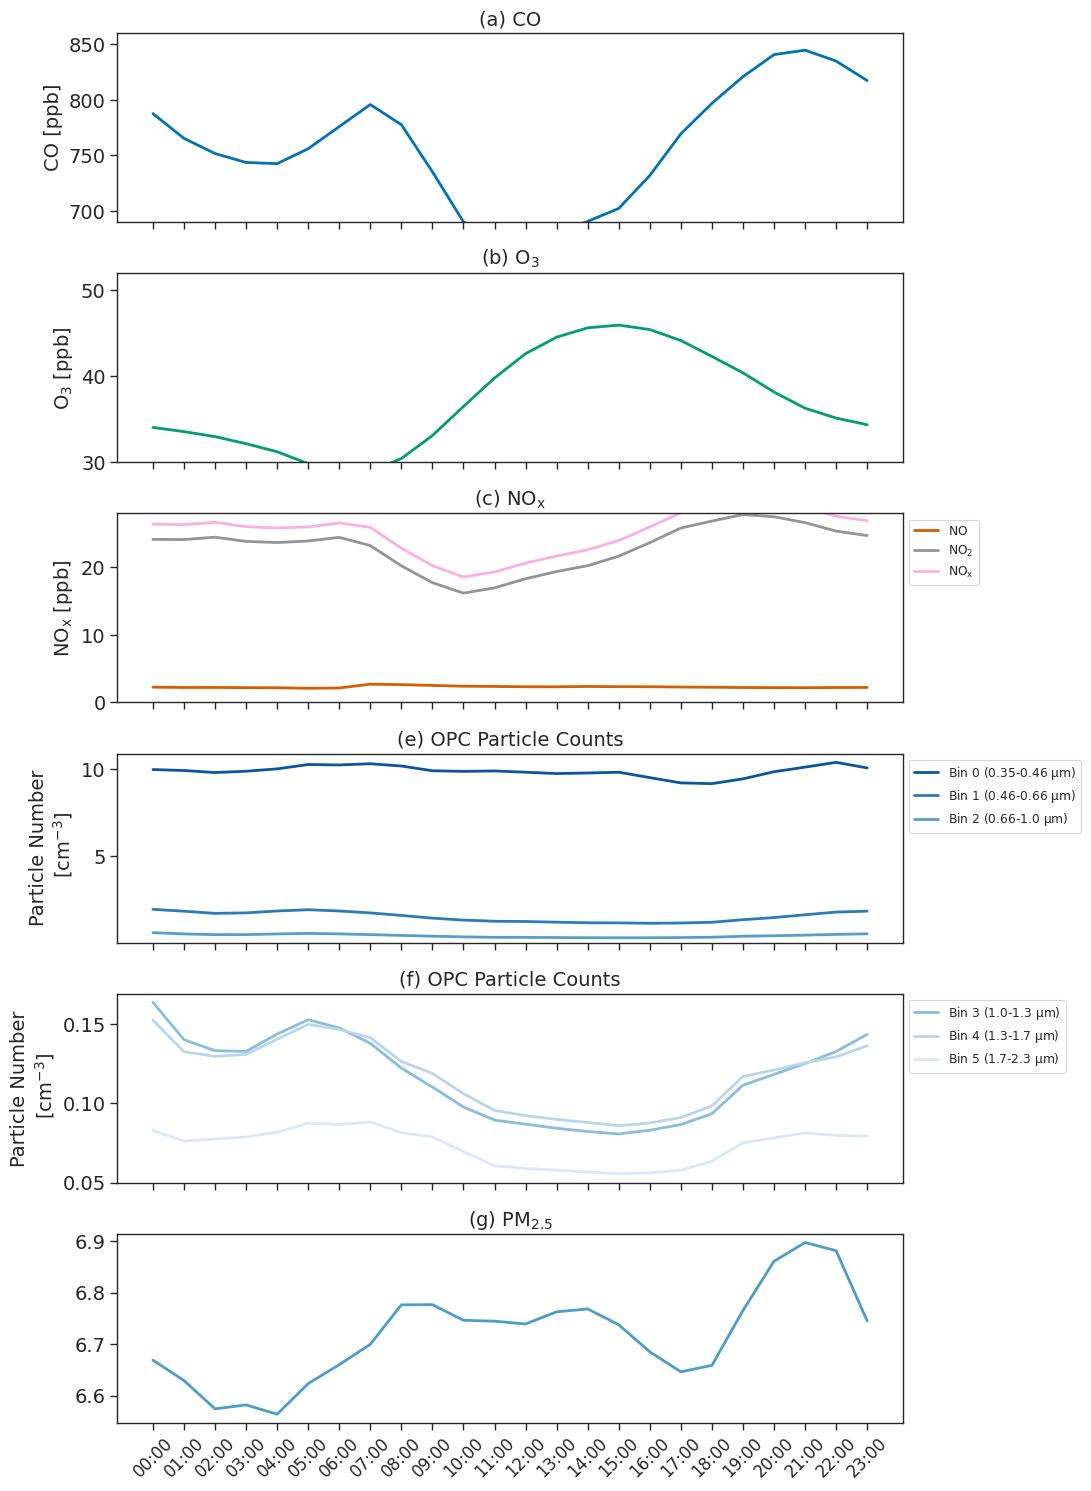

In [12]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('MOD-00679/dirunal_MOD-000679_allfeatures.png')

## Diurnal by Season

In [13]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [14]:
ts_hour = ts_hour.reset_index()

In [15]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-04-15 08:00:00,5.131208,0.591750,0.218333,0.066500,0.064708,0.032875,8.764208,NaN,NaN,NaN,NaN,36.575000,22.020833,6.701576,8,Spring
1,2025-04-25 10:00:00,2.892933,0.370733,0.137533,0.042533,0.031000,0.013733,3.812400,NaN,NaN,NaN,NaN,38.166667,23.046667,5.315429,10,Spring
2,2025-04-25 11:00:00,2.891000,0.350600,0.123000,0.041200,0.032200,0.010200,3.761200,NaN,NaN,NaN,NaN,41.160000,23.180000,5.378678,11,Spring
3,2025-04-25 12:00:00,6.251560,0.860040,0.320480,0.102760,0.138800,0.092240,9.620120,NaN,NaN,NaN,NaN,29.908000,28.064000,7.098788,12,Spring
4,2025-04-25 13:00:00,7.201600,0.838100,0.351233,0.113567,0.142867,0.093833,10.760467,1224.4478,72.87552,5.96976,6.93636,30.555000,29.026667,7.502272,13,Spring


In [16]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                               
Autumn 0     5.205489  1.041344  0.401234  0.120474  0.119633  0.067936   
       1     5.405053  0.916715  0.308385  0.088137  0.091170  0.061210   
       2     5.634090  0.899874  0.298649  0.087684  0.094189  0.065266   
       3     5.959480  0.955539  0.308208  0.090941  0.097560  0.067346   
       4     6.229537  1.085170  0.342562  0.094784  0.096348  0.062014   
...               ...       ...       ...       ...       ...       ...   
Winter 19    7.860888  1.167814  0.327264  0.081657  0.070379  0.037328   
       20    8.005445  1.228363  0.342632  0.084781  0.071890  0.039399   
       21    8.105208  1.329394  0.369620  0.092949  0.077510  0.040595   
       22    8.932484  1.716310  0.482651  0.124350  0.113906  0.057825   
       23    9.607787  1.988491  0.525553  0.119465  0.103674  0.056089   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     5.309360  750.635207  31.718278  2.354918  26.302657  60.998371   
       1     5.281955  744.620137  30.993370  2.274396  26.338334  62.930431   
       2     5.201795  740.261539  30.275254  2.363060  27.030419  64.653253   
       3     5.281340  736.901512  29.579411  2.297658  26.426514  66.009557   
       4     5.021127  728.053183  28.975988  2.303301  26.197600  67.160543   
...               ...         ...        ...       ...        ...        ...   
Winter 19    6.459929  757.632372  28.277157  2.165859  29.375189  55.956034   
       20    6.017206  763.299814  28.018107  2.235166  29.183725  56.553621   
       21    5.993817  764.731291  27.838614  2.239014  29.082909  57.162759   
       22    6.016151  749.955208  27.777184  2.253260  29.237955  58.918506   
       23    6.082544  749.911151  27.234274  2.319847  29.142007  60.514770   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.275225  5.920911  
       1     14.837818  5.937244  
       2     14.470643  5.936345  
       3     14.150658  5.976602  
       4     13.859438  5.912121  
...                ...       ...  
Winter 19     2.253563  5.491682  
       20     1.995460  5.361187  
       21     1.830920  5.360610  
       22     1.662931  5.401004  
       23     1.443736  5.448139  

[96 rows x 14 columns]

In [17]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,5.205489,1.041344,0.401234,0.120474,0.119633,0.067936,5.309360,750.635207,31.718278,2.354918,26.302657,60.998371,15.275225,5.920911
1,Autumn,1,5.405053,0.916715,0.308385,0.088137,0.091170,0.061210,5.281955,744.620137,30.993370,2.274396,26.338334,62.930431,14.837818,5.937244
2,Autumn,2,5.634090,0.899874,0.298649,0.087684,0.094189,0.065266,5.201795,740.261539,30.275254,2.363060,27.030419,64.653253,14.470643,5.936345
3,Autumn,3,5.959480,0.955539,0.308208,0.090941,0.097560,0.067346,5.281340,736.901512,29.579411,2.297658,26.426514,66.009557,14.150658,5.976602
4,Autumn,4,6.229537,1.085170,0.342562,0.094784,0.096348,0.062014,5.021127,728.053183,28.975988,2.303301,26.197600,67.160543,13.859438,5.912121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,7.860888,1.167814,0.327264,0.081657,0.070379,0.037328,6.459929,757.632372,28.277157,2.165859,29.375189,55.956034,2.253563,5.491682
92,Winter,20,8.005445,1.228363,0.342632,0.084781,0.071890,0.039399,6.017206,763.299814,28.018107,2.235166,29.183725,56.553621,1.995460,5.361187
93,Winter,21,8.105208,1.329394,0.369620,0.092949,0.077510,0.040595,5.993817,764.731291,27.838614,2.239014,29.082909,57.162759,1.830920,5.360610
94,Winter,22,8.932484,1.716310,0.482651,0.124350,0.113906,0.057825,6.016151,749.955208,27.777184,2.253260,29.237955,58.918506,1.662931,5.401004


In [18]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [19]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,5.205489,1.041344,0.401234,0.120474,0.119633,0.067936,5.309360,750.635207,31.718278,2.354918,26.302657,60.998371,15.275225,5.920911
01:00,Autumn,1,5.405053,0.916715,0.308385,0.088137,0.091170,0.061210,5.281955,744.620137,30.993370,2.274396,26.338334,62.930431,14.837818,5.937244
02:00,Autumn,2,5.634090,0.899874,0.298649,0.087684,0.094189,0.065266,5.201795,740.261539,30.275254,2.363060,27.030419,64.653253,14.470643,5.936345
03:00,Autumn,3,5.959480,0.955539,0.308208,0.090941,0.097560,0.067346,5.281340,736.901512,29.579411,2.297658,26.426514,66.009557,14.150658,5.976602
04:00,Autumn,4,6.229537,1.085170,0.342562,0.094784,0.096348,0.062014,5.021127,728.053183,28.975988,2.303301,26.197600,67.160543,13.859438,5.912121
05:00,Autumn,5,6.788433,1.257747,0.390474,0.102982,0.100731,0.061910,5.176032,744.636446,27.618432,2.105457,26.295113,68.433202,13.629120,5.977310
06:00,Autumn,6,7.011055,1.322620,0.393440,0.103861,0.100662,0.061179,5.290679,763.389780,26.330175,2.016059,27.105647,69.406321,13.371029,6.021926
07:00,Autumn,7,7.225149,1.201918,0.361259,0.098382,0.099710,0.063681,5.652211,801.429029,26.154532,2.370287,27.337530,68.267509,13.655531,6.116556
08:00,Autumn,8,6.767551,1.004039,0.311554,0.089644,0.096674,0.065378,6.054772,794.204327,27.443065,2.422363,24.362192,63.033663,15.211319,6.188696
09:00,Autumn,9,5.769423,0.840151,0.281505,0.083455,0.092676,0.063176,6.165538,739.695005,29.697493,2.528424,19.824058,52.655495,18.632344,6.143679


In [20]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-459/1655991102.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-459/1655991102.py:41: SyntaxWarning: invalid escape sequen

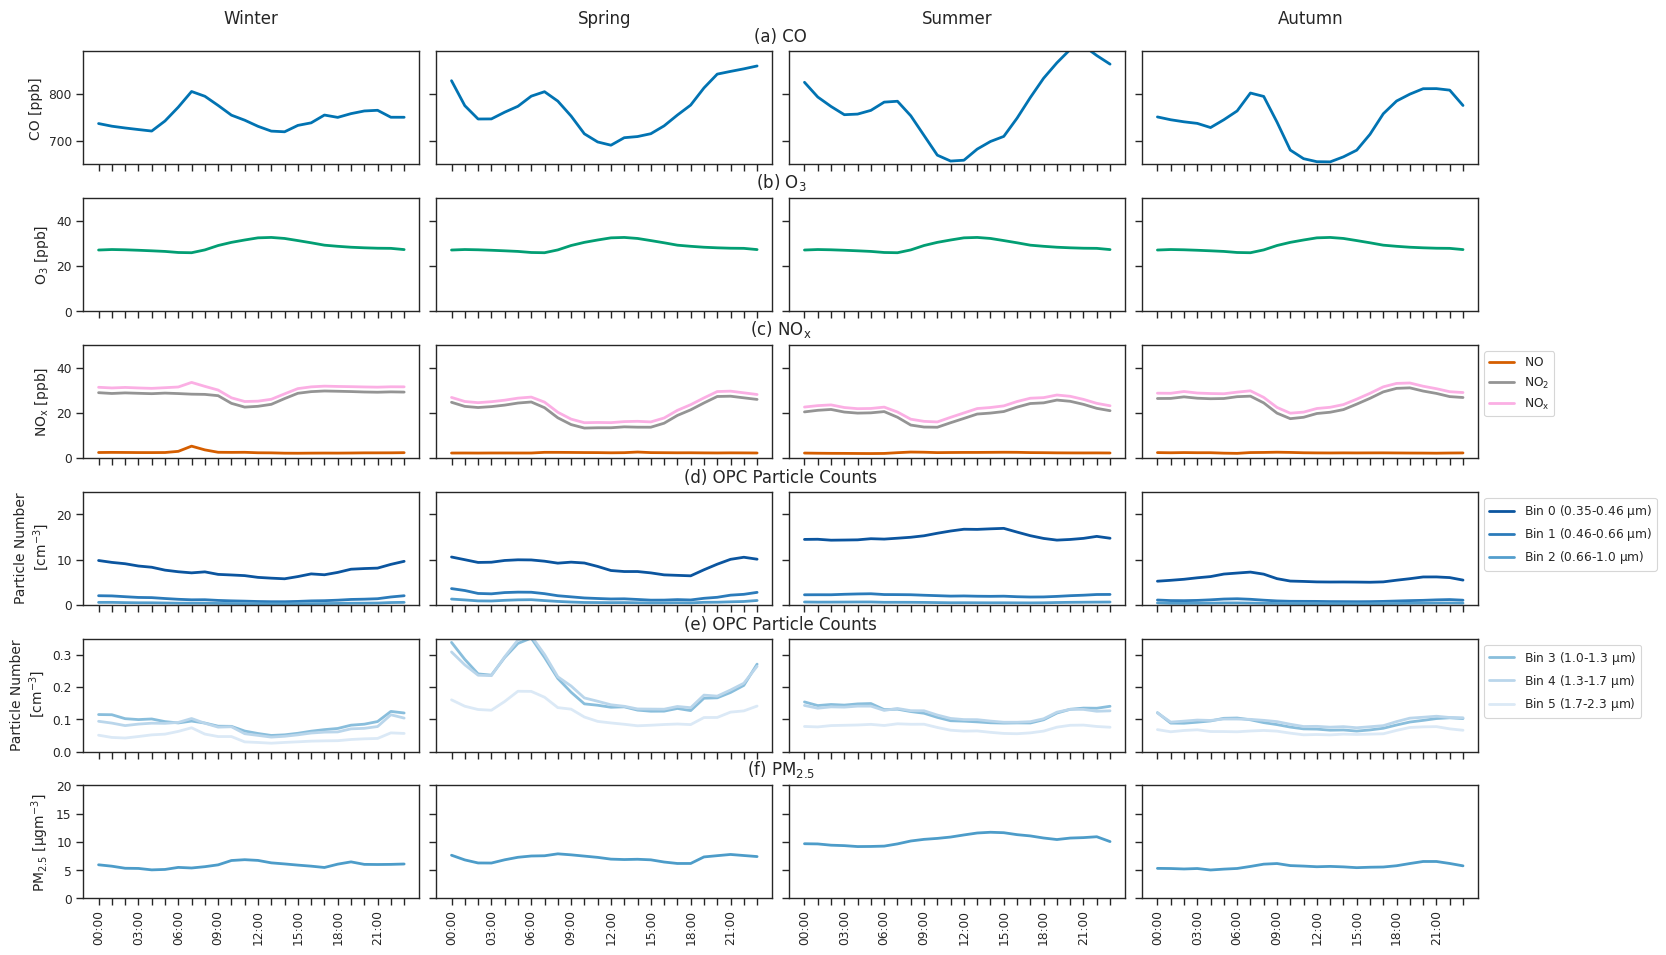

In [21]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('MOD-00679/diurnal_by_season_MOD-000679.png')